In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
from pathlib import Path
from useful_functions import *

In [2]:
OII_rest    = air2vac(lines_air['OII'])
NII_rest    = air2vac(lines_air['NII'])
Hbeta_rest  = air2vac(lines_air['Hbeta'])
Halpha_rest = air2vac(lines_air['Halpha'])
SII_rest    = air2vac(lines_air['SII'])
CaII_rest   = air2vac(lines_air['CaII'])
NaD_rest    = air2vac(lines_air['NaD'])

In [3]:
spectra_data = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
spectrum = Spectrum(spectra_data, color_data)

In [4]:
# blue_crit = spectrum.color_criteria(criterion='g-r<0.75', exclude=False)
# # spectrum.add_label(label_type='blue', criteria=blue_crit)

# qso_crit = spectrum.subtype_criteria(subtype='QSO', exclude=False)
# # spectrum.add_label(label_type='QSO', criteria=qso_crit)

# spectrum.subset(criteria=blue_crit & qso_crit)

In [5]:
# spectrum.shrink_dataset(10)

In [6]:
example_targetID = 39627775715312061
example_index = spectrum.id2index(example_targetID)
targetid_example = spectrum.targetID[example_index]
# flux = spectrum.smoothed_flux[example_index, :]
z = spectrum.z_pipe[example_index]

In [7]:
flux = spectrum.smoothed_flux[example_index]

In [8]:
# idx = spectrum.id2index(39627806199518614)
# dz = spectrum.adjust_z(idx, mode='base_2')
# print(dz)

In [9]:
# plt.step(desi_wavelength, flux, where='mid')
# plt.show()

In [10]:
popt = spectrum.fit_flux(i=example_index, lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=True, fit_z=False)
print(popt)
sigma_1, sigma_2, dlam, conti_a, conti_b = popt[0], popt[1], popt[-3], popt[-2], popt[-1]
fixed_comp = []
free_comp = []
for k in range(len([*Halpha_rest, *NII_rest, *SII_rest])):
    fixed_comp.append((popt[k+2], [*Halpha_rest, *NII_rest, *SII_rest][k]*(1+z), sigma_1))
    free_comp.append((popt[(k+len([*Halpha_rest, *NII_rest, *SII_rest]))+2], ([*Halpha_rest, *NII_rest, *SII_rest][k]+dlam)*(1+z), sigma_2))
fitted_model = model(desi_wavelength, gaussian_parms=(fixed_comp+free_comp), conti_parms=(conti_a, conti_b))
fixed_model = model(desi_wavelength, gaussian_parms=fixed_comp, conti_parms=(conti_a, conti_b))
free_model = model(desi_wavelength, gaussian_parms=free_comp, conti_parms=(conti_a, conti_b))

[ 3.15941078e+00  1.47431521e+00  5.71093258e+00  2.04920218e+00
  1.05035814e+01  2.88709070e+00  1.62475660e+00  5.12577116e+00
  2.89493987e+00  1.88070639e-17  1.00649487e-20  4.74932996e-01
 -1.16345070e+00  5.87549936e-04  5.69647400e+00]


In [11]:
popt = spectrum.fit_flux(i=example_index, lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=True, fit_z=True)
print(popt)
dz, sigma_1, sigma_2, dlam, conti_a, conti_b = popt[0], popt[1], popt[2], popt[-3], popt[-2], popt[-1]
fixed_comp = []
free_comp = []
for k in range(len([*Halpha_rest, *NII_rest, *SII_rest])):
    fixed_comp.append((popt[k+2], [*Halpha_rest, *NII_rest, *SII_rest][k]*(1+z+dz), sigma_1))
    free_comp.append((popt[(k+len([*Halpha_rest, *NII_rest, *SII_rest]))+2], ([*Halpha_rest, *NII_rest, *SII_rest][k]+dlam)*(1+z+dz), sigma_2))
fitted_model = model(desi_wavelength, gaussian_parms=(fixed_comp+free_comp), conti_parms=(conti_a, conti_b))
fixed_model = model(desi_wavelength, gaussian_parms=fixed_comp, conti_parms=(conti_a, conti_b))
free_model = model(desi_wavelength, gaussian_parms=free_comp, conti_parms=(conti_a, conti_b))

Try without fit_z ...


RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

In [ ]:
# popt = spectrum.fit_flux(i=example_index, lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=False, fit_z=False)
# sigma_1, offset, conti_a, conti_b = popt[0], popt[-3], popt[-2], popt[-1]
# print(popt)
# offset_comp = []
# for k in range(len([*Halpha_rest, *NII_rest, *SII_rest])):
#     offset_comp.append((popt[k+1], ([*Halpha_rest, *NII_rest, *SII_rest][k]+offset)*(1+z), sigma_1))
# fitted_model = model(desi_wavelength, gaussian_parms=offset_comp, conti_parms=(conti_a, conti_b))

In [ ]:
# popt = spectrum.fit_flux(i=example_index, lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=False, fit_z=True)
# dz, sigma_1, offset, conti_a, conti_b = popt[0], popt[1], popt[-3], popt[-2], popt[-1]
# print(popt)
# offset_comp = []
# for k in range(len([*Halpha_rest, *NII_rest, *SII_rest])):
#     offset_comp.append((popt[k+2], ([*Halpha_rest, *NII_rest, *SII_rest][k]+offset)*(1+z+dz), sigma_1))
# fitted_model = model(desi_wavelength, gaussian_parms=offset_comp, conti_parms=(conti_a, conti_b))

(0.0, 21.771500035504108)

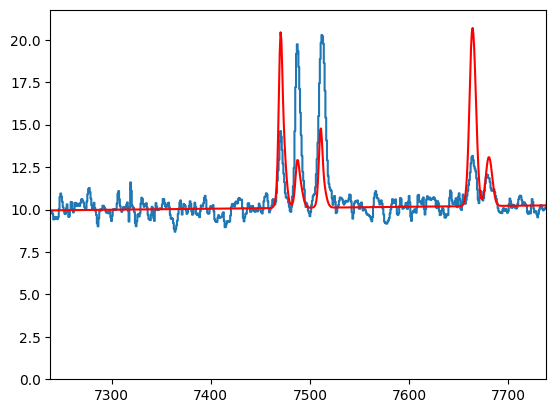

In [ ]:
plt.step(desi_wavelength, flux, where='mid', label='data')
plt.plot(desi_wavelength, fitted_model, color='red', label='fit')
# plt.plot(desi_wavelength, fixed_model, color='green', linestyle='--', label='fixed comp.')
# plt.plot(desi_wavelength, free_model, color='orange', linestyle='--', label='free comp.')
plt.xlim((Halpha_rest[0]*(1+z)-250, Halpha_rest[0]*(1+z)+250))
plt.ylim(bottom=0)

In [ ]:
# # if os.path.exists('adjusted_z_mode.txt'): os.remove('adjusted_z_mode.txt')
# for id in spectrum.targetID:
#     idx = spectrum.id2index(id)
#     spectrum.adjust_z(idx, mode='base_2')
#     if spectrum.adjust_z_mode[idx] not in spectrum.target_label[idx]:
#         spectrum.add_label(label_type=spectrum.adjust_z_mode[idx], i=idx)
#     print(spectrum.target_label[idx])

In [ ]:
# if os.path.exists('NaD_detection.txt'): os.remove('NaD_detection.txt')
# if os.path.exists('inflow_candidates.txt'): os.remove('inflow_candidates.txt')
# if os.path.exists('outflow_candidates.txt'): os.remove('outflow_candidates.txt')

# for id in spectrum.targetID:
#     idx = spectrum.id2index(id)
#     popt = spectrum.fit_flux(i=idx, lam0=[*NaD_rest], fit_z=False, two_component=False, record_detection='NaD', 
#                       e_or_a='a')
#     if popt is not None:
#         dlam = popt[-3]
#     if 'NaD' in spectrum.line_detections[idx]:
#         with open('NaD_detection.txt', 'a') as f:
#             f.write(f"{id} NaD\n")
#         if 'NaD' not in spectrum.target_label[idx]:
#             spectrum.add_label(i=idx, label_type='NaD')
#             if dlam > 0.8:
#                 with open('inflow_candidates.txt', 'a') as f:
#                     f.write(f"{id} NaD {dlam:.5f}\n")
#                 if 'inflow' not in spectrum.target_label[idx]:
#                     spectrum.add_label(label_type='inflow', label_at=idx)
#             elif dlam < -0.8:
#                 with open('outflow_candidates.txt', 'a') as f:
#                     f.write(f"{id} NaD {dlam:.5f}\n")
#                 if 'outflow' not in spectrum.target_label[idx]:
#                     spectrum.add_label(label_type='outflow', label_at=idx)
#     print(spectrum.target_label[idx])